Route: [1, 7, 5, 4, 6, 3, 2]
Optimal value: 22.0 meters


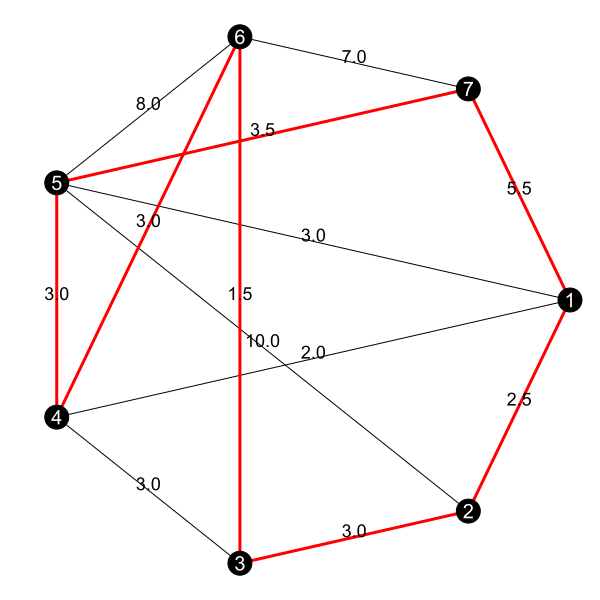

In [2]:
using JuMP                  # Modeling language
using HiGHS                 # Solver
using CSV                   # CSV file handling
using DataFrames            # Dataframe handling
using Graphs                # For graph data structures
using SimpleWeightedGraphs  # For weighted graphs
using Karnak                # For drawing graphs
using Colors                # For color manipulation

# Utility functions for TSP solution plotting
function plot_tsp_solution(points, x_opt)
    # Extract the route from the solution
    route = [(coord[1], coord[2]) for coord in findall(x_opt .> 0.5)]

    # Create a weighted directed graph with n vertices
    g = SimpleWeightedGraph(points.From, points.To, points.Distance)

    # Define a function to check if an edge is part of the route
    function is_in_route(e, route)
        return (e.src, e.dst) in route || (e.dst, e.src) in route ? true : false
    end

    # Draw graph
    @drawsvg begin
        background("white")
        sethue("black")
        fontsize(20)
        drawgraph(
            g,
            vertexshapesizes = 12,
            vertexlabels = 1:nv(g),
            edgelabels = [g.weights[e.src, e.dst] for e in edges(g)],
            edgelabelfontsizes = 18,
            edgestrokecolors = [is_in_route(e, route) ? RGB(1, 0, 0) : RGB(0, 0, 0) for e in edges(g)],
            edgestrokeweights = [is_in_route(e, route) ? 3 : 1 for e in edges(g)]
        )
    end
end

# Function to solve TSP using MTZ formulation
function solve_tsp_mtz(file_path)

    # Load the CSV file containing the TSP data
    points = CSV.read(file_path, DataFrame)

    # Number of points
    n = max(maximum(points.From), maximum(points.To))

    # Create the distance matrix
    D = fill(100000.0, n, n)
    for row in eachrow(points)
        u = row[:From]
        v = row[:To]
        w = row[:Distance]
        D[u, v] = D[v, u] = w
    end

    # Create model
    model = JuMP.Model(HiGHS.Optimizer)

    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Define the decision variables
    @variable(model, x[1:n, 1:n], Bin)

    # Define the MTZ variables
    @variable(model, u[2:n])

    # Objective function: minimize total distance
    @objective(model, Min, sum(D[i,j] * x[i,j] for i in 1:n, j in 1:n))

    # Constraints to eliminate self-loops
    @constraint(model, [i=1:n], x[i,i] == 0)

    # Each column sums to 1 (each location visited once)
    @constraint(model, [j=1:n], sum(x[i,j] for i in 1:n) == 1)

    # Each row sums to 1 (each location departs once)
    @constraint(model, [i=1:n], sum(x[i,j] for j in 1:n) == 1)

    # MTZ constraints
    @constraint(model, [i=2:n, j=2:n], n * x[i,j] - (n - 1) <= u[j] - u[i])

    # Run the solver
    JuMP.optimize!(model)

    # Get the values of the decision variables
    x_opt = JuMP.value.(x)

    # Extract the routes from the solution
    route = [1]
    while true
        to = findfirst(x_opt[route[end], :] .> 0.5)
        to == 1 ? break : push!(route, to)
    end
    println("Route: $route")

    # Get the optimal value of the objective function
    z_opt = JuMP.objective_value(model)
    println("Optimal value: $z_opt meters")

    # Plot the solution on the map
    plot_tsp_solution(points, x_opt);
end

# Example usage
solve_tsp_mtz("data/tsp_exercise.csv")